/tmp/ipykernel_36701/2777322829.py:14: RuntimeWarning: invalid value encountered in sqrt
  dist = np.sqrt(np.sum(diff**2, axis=2))  # shape (h, w)


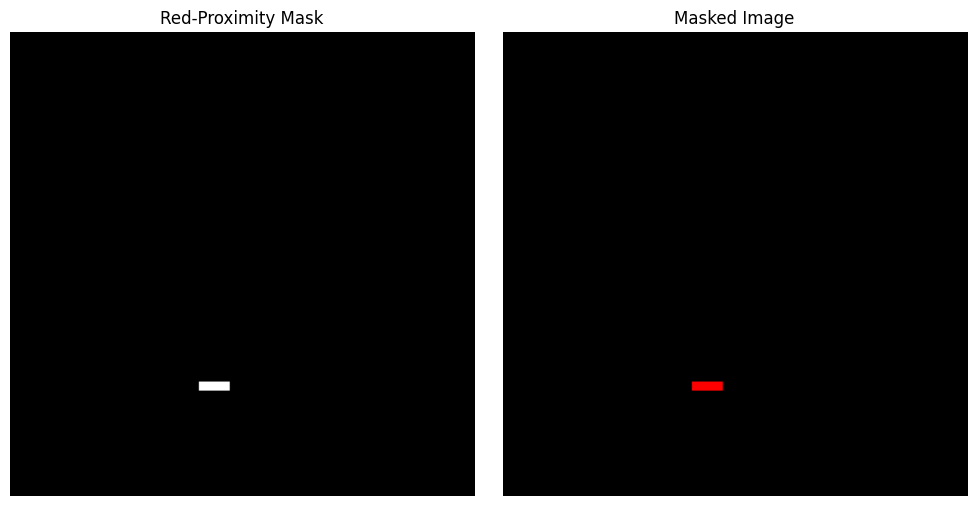

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

# (after you’ve computed `mask` and `masked` as above)
# Load your image
img = cv2.imread('40031.png')  # BGR format

# Define the target red color in BGR
target = np.array([0, 0, 255], dtype=np.int16)

# Compute per-pixel Euclidean distance from the target color
diff = img.astype(np.int16) - target  # shape (h, w, 3)
dist = np.sqrt(np.sum(diff**2, axis=2))  # shape (h, w)


max_dist = 0  # adjust: lower = more strict, higher = more lenient
mask = (dist <= max_dist).astype(np.uint8) * 255  # binary mask

# Apply mask
masked = cv2.bitwise_and(img, img, mask=mask)

# Convert BGR→RGB for correct color display
masked_rgb = cv2.cvtColor(masked, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Show the binary mask
axes[0].imshow(mask, cmap='gray')
axes[0].set_title('Red-Proximity Mask')
axes[0].axis('off')

# Show the masked image
axes[1].imshow(masked_rgb)
axes[1].set_title('Masked Image')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import os
import cv2
import numpy as np
from glob import glob
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from skimage.measure import moments, moments_hu
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
import matplotlib.pyplot as plt

# 1. CONFIG
IMG_DIR       = "../data/Tell2Design Data/General Data/floorplan_reoriented"
# N_CLUSTERS    = 10
SAVE_LABELS   = "plan_labels.csv"
OUTPUT_CSV    = "extracted_features.csv"

BATCH_SIZE = 32
EPOCHS = 15
LEARNING_RATE = 1e-3
LATENT_DIM = 64
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. COLOR DEFINITIONS (BGR in OpenCV)
LIVING_COLOR = (0xAA, 0xE8, 0xEE)  # given as (R,G,B); flip to (B,G,R)
ENTRANCE_COLOR= (0,0,255)                 # pure red
# We assume everything non-white/non-red/non-living is “outer wall” 
# (or you could detect the black border via Canny+findContours)

def extract_masks(img):
    """
    Return:
      - outer_mask: interior of the main wall boundary (white), exterior is black.
      - living_mask: binary mask of living-room region.
      - entrance_mask: binary mask of red entrance pixels.
    """
    # 1) Living-room mask
    living_mask   = cv2.inRange(img, np.array(LIVING_COLOR), np.array(LIVING_COLOR))

    # 2) Entrance mask
    entrance_mask = cv2.inRange(img, np.array(ENTRANCE_COLOR), np.array(ENTRANCE_COLOR))

    # 3) Wall boundary mask: black walls + entrance
    #    - walls: pixels that are (0,0,0) in BGR
    wall_mask = cv2.inRange(img, np.array([0,0,0]), np.array([0,0,0]))
    boundary_mask = cv2.bitwise_or(wall_mask, entrance_mask)

    # 4) Find largest closed contour of boundary
    #    a) find all contours in the boundary mask
    contours, _ = cv2.findContours(boundary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    #    b) pick the largest by area
    if contours:
        main_contour = max(contours, key=cv2.contourArea)
        # 5) Fill the contour to get the interior
        interior_mask = np.zeros_like(boundary_mask)
        cv2.drawContours(interior_mask, [main_contour], -1, color=255, thickness=cv2.FILLED)
        outer_mask = interior_mask  # white = interior, black = exterior
    else:
        # Fallback: treat whole image as interior
        outer_mask = np.ones_like(boundary_mask) * 255

    return outer_mask, living_mask, entrance_mask

def hu_vector(mask):
    """Compute first 7 Hu moments of a binary mask, log-transformed."""
    m = moments(mask.astype(np.uint8), order=3)
    hu = moments_hu(m)
    # log‐scale to reduce dynamic range
    return -np.sign(hu) * np.log10(np.abs(hu) + 1e-12)

def entrance_centroid(mask):
    """Return (x,y) of red entrance pixels, normalized to [0,1]."""
    ys, xs = np.where(mask>0)
    if len(xs)==0:
        return (np.nan, np.nan)
    x_mean = xs.mean()/mask.shape[1]
    y_mean = ys.mean()/mask.shape[0]
    return (x_mean, y_mean)

class FloorplanDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.files = glob(os.path.join(img_dir, "*.png"))
        self.transform = transform or transforms.ToTensor()
    def __len__(self):
        return len(self.files)
    def __getitem__(self, idx):
        img = cv2.imread(self.files[idx])
        # split channels: outer (1), living (1), entrance (1)
        outer, living, entr = extract_masks(img)
        # stack and normalize to [0,1]
        x = np.stack([outer, living, entr], axis=2) / 255.0
        x = self.transform(x)  # shape [3,256,256]
        return x, self.files[idx]

In [ ]:
class ConvAutoencoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),  
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), 
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.ReLU(),
            nn.Flatten(),              
            nn.Linear(256*16*16, latent_dim)
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256*16*16),
            nn.Unflatten(1, (256,16,16)),
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, 4, 2, 1), 
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), 
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),   
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),   
            nn.Sigmoid()
        )
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

In [ ]:
dataset = FloorplanDataset(IMG_DIR)
loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
model = ConvAutoencoder(LATENT_DIM).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.MSELoss()

for epoch in range(1, EPOCHS+1):
    model.train()
    total_loss = 0
    for xb, _ in loader:
        xb = xb.to(DEVICE, dtype=torch.float32)
        recon, _ = model(xb)
        loss = criterion(recon, xb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    print(f"Epoch {epoch}/{EPOCHS}, Loss: {total_loss/len(dataset):.4f}")





Epoch 1/20, Loss: 0.0089
Epoch 2/20, Loss: 0.0034
Epoch 3/20, Loss: 0.0026
Epoch 4/20, Loss: 0.0022
Epoch 5/20, Loss: 0.0019
Epoch 6/20, Loss: 0.0017
Epoch 7/20, Loss: 0.0016
Epoch 8/20, Loss: 0.0015
Epoch 9/20, Loss: 0.0014
Epoch 10/20, Loss: 0.0013
Epoch 11/20, Loss: 0.0012
Epoch 12/20, Loss: 0.0012
Epoch 13/20, Loss: 0.0011
Epoch 14/20, Loss: 0.0011
Epoch 15/20, Loss: 0.0010
Epoch 16/20, Loss: 0.0010
Epoch 17/20, Loss: 0.0009
Epoch 18/20, Loss: 0.0009
Epoch 19/20, Loss: 0.0009
Epoch 20/20, Loss: 0.0009


In [8]:
model.eval()
codes = []
files = []
with torch.no_grad():
    for xb, fnames in DataLoader(dataset, batch_size=BATCH_SIZE):
        xb = xb.to(DEVICE, dtype=torch.float32)
        _, z = model(xb)
        codes.append(z.cpu().numpy())
        files.extend(fnames)
codes = np.vstack(codes)

KeyboardInterrupt: 

In [9]:
model.eval()
codes, filenames = [], []
with torch.no_grad():
    for xb, fnames in DataLoader(dataset, batch_size=BATCH_SIZE):
        xb = xb.to(DEVICE, dtype=torch.float32)
        _, z = model(xb)
        codes.append(z.cpu().numpy())
        filenames.extend(fnames)
codes = np.vstack(codes)

In [4]:
import pandas as pd

In [10]:
feat_df = pd.DataFrame(codes, columns=[f"z_{i}" for i in range(LATENT_DIM)])
feat_df.insert(0, "filename", filenames)
feat_df.to_csv("autoencoder_features.csv", index=False)
print("Saved autoencoder latent features to 'autoencoder_features.csv'")


Saved autoencoder latent features to 'autoencoder_features.csv'


In [33]:
FEATURE_CSV = "autoencoder_features.csv"  # or your features file
K_RANGE = range(4, 31)

# === LOAD FEATURES ===
df = pd.read_csv(FEATURE_CSV)
df['filename'] = df['filename'].str.split('/').str[-1]

nnary_df = pd.read_csv("./nnary_features_40000.csv")['filename']

df = df.merge(nnary_df, on="filename", how="inner")
feature_cols = [c for c in df.columns if c != "filename"]
X = df[feature_cols].values

In [36]:
df

,filename,z_0,z_1,z_2,z_3,z_4,z_5,z_6,z_7,z_8,...,z_54,z_55,z_56,z_57,z_58,z_59,z_60,z_61,z_62,z_63
0,40795.png,4.108797,10.172802,-7.455968,-1.229421,-1.493096,5.379216,1.562885,-0.985730,-6.225344,...,2.691973,4.269640,4.178942,-5.304331,-4.942420,-0.487846,11.354354,1.763183,-8.509821,-2.375585
1,60259.png,-1.845174,5.587177,1.386902,-1.809291,1.177749,-0.684780,-5.165852,-13.284626,6.748463,...,-0.066598,-12.240501,2.444211,-4.039306,-3.002860,2.729901,-8.032515,-4.417750,-6.311451,-4.302019
2,45409.png,-11.965846,-6.427396,1.710768,-7.839262,6.194621,9.227719,2.680041,-2.173681,-13.096289,...,-3.756053,0.177937,2.516696,1.442089,-4.426959,-1.449695,6.533363,0.205934,-10.386169,1.081487
3,22733.png,3.665130,-3.949741,-6.894859,0.533769,2.424829,-4.385708,-5.764265,-1.880337,-4.094491,...,1.498706,5.983512,-4.586871,7.597534,-0.396937,-3.160147,3.616680,-3.408828,0.122812,-3.110550
4,25886.png,0.403936,-5.567141,-3.840472,-1.771699,-5.978360,-2.753562,-4.180788,-4.582154,2.679868,...,0.521015,7.368257,-6.657928,8.817045,-5.940941,-13.785778,3.067271,-2.841557,-1.269459,-5.682622
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,2951.png,-1.382273,-2.106232,-4.673338,-5.158836,-3.556019,-4.069418,-9.526835,-4.739200,-11.956424,...,-1.511454,-0.311833,7.244244,0.048950,-4.854567,-6.223732,0.378236,-2.212828,-4.547205,-3.533816
39996,77295.png,-2.352907,-1.497769,10.335649,-8.924531,-4.726086,6.901804,-4.462527,-4.145254,-3.829518,...,-2.835612,2.311253,-1.242320,0.041862,-7.240480,-1.215655,-2.681615,-6.053023,-0.113973,0.900375
39997,19767.png,-0.505042,-3.410470,0.003846,6.375595,4.460257,6.593107,-0.683379,-1.084538,3.831217,...,-3.195683,1.586459,-0.877457,6.164741,-6.189335,10.024885,5.655015,-2.343304,3.468994,-7.845638
39998,21304.png,4.806303,5.131151,-0.103753,11.915888,-0.618780,7.518101,-3.246840,1.480263,-0.311854,...,-3.987549,-3.611657,7.293170,-1.733385,-8.694510,-0.173607,-4.093465,9.148315,-1.552331,4.462805


4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30


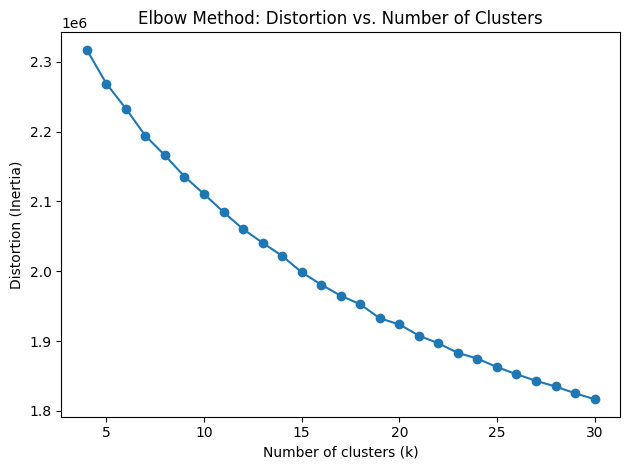

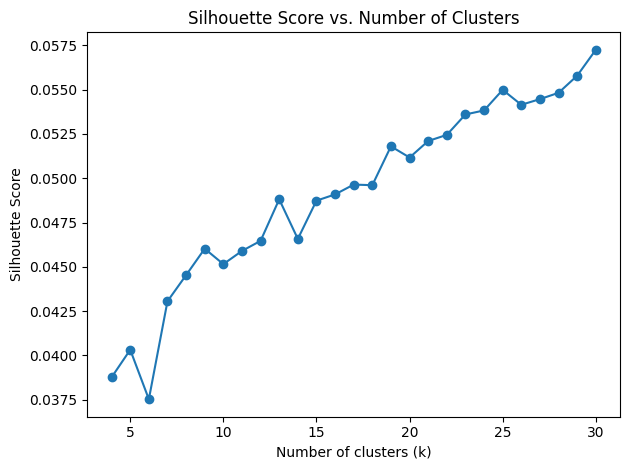

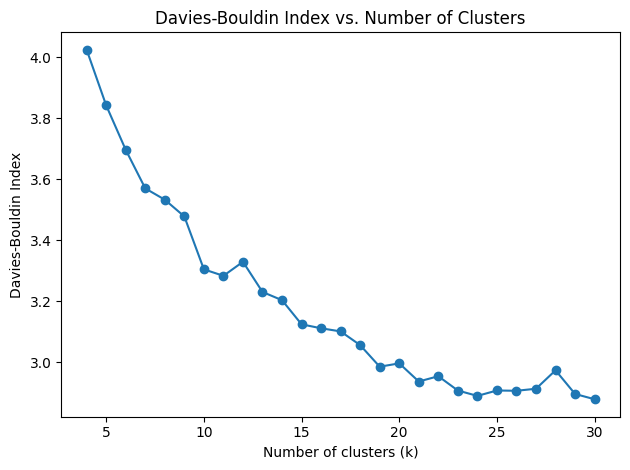

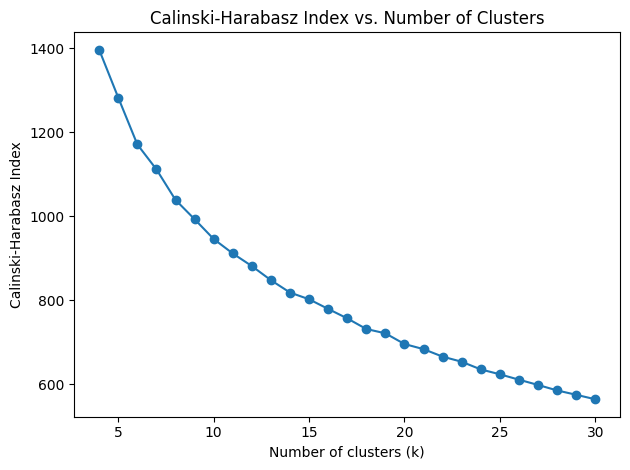

Final clustering with k=10 saved to 'clustered_features.csv'


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === CLUSTERING EVALUATION ===
inertias = []
silhouettes = []
db_indices = []
ch_indices = []

for k in K_RANGE:
    print(k)
    kmeans = KMeans(n_clusters=k, random_state=0)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    db_indices.append(davies_bouldin_score(X_scaled, labels))
    ch_indices.append(calinski_harabasz_score(X_scaled, labels))

# === PLOTTING ===
# 1. Distortion (Inertia)
plt.figure()
plt.plot(list(K_RANGE), inertias, marker='o')
plt.title("Elbow Method: Distortion vs. Number of Clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Distortion (Inertia)")
plt.tight_layout()
plt.show()

# 2. Silhouette Score
plt.figure()
plt.plot(list(K_RANGE), silhouettes, marker='o')
plt.title("Silhouette Score vs. Number of Clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

# 3. Davies-Bouldin Index
plt.figure()
plt.plot(list(K_RANGE), db_indices, marker='o')
plt.title("Davies-Bouldin Index vs. Number of Clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Davies-Bouldin Index")
plt.tight_layout()
plt.show()

# 4. Calinski-Harabasz Index
plt.figure()
plt.plot(list(K_RANGE), ch_indices, marker='o')
plt.title("Calinski-Harabasz Index vs. Number of Clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Calinski-Harabasz Index")
plt.tight_layout()
plt.show()


BEST_K = 10  # choose based on the above plots
kmeans_final = KMeans(n_clusters=BEST_K, random_state=0).fit(X_scaled)
df["cluster"] = kmeans_final.labels_
df.to_csv("clustered_features.csv", index=False)
print(f"Final clustering with k={BEST_K} saved to 'clustered_features.csv'")

30
32
34
36
38
40
42
44
46
48


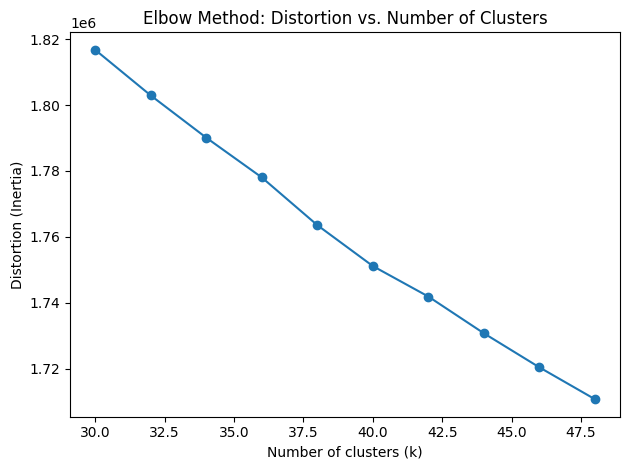

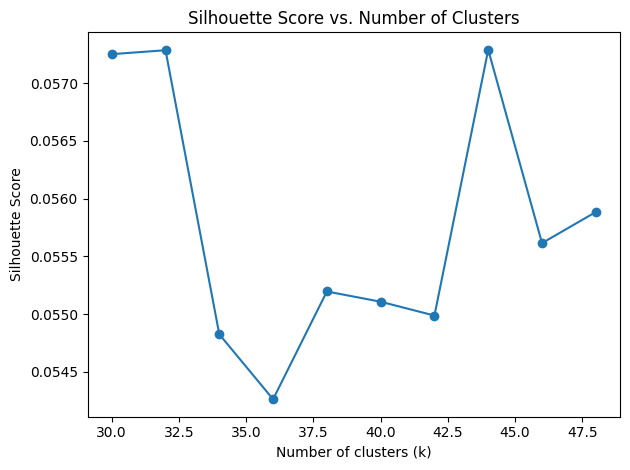

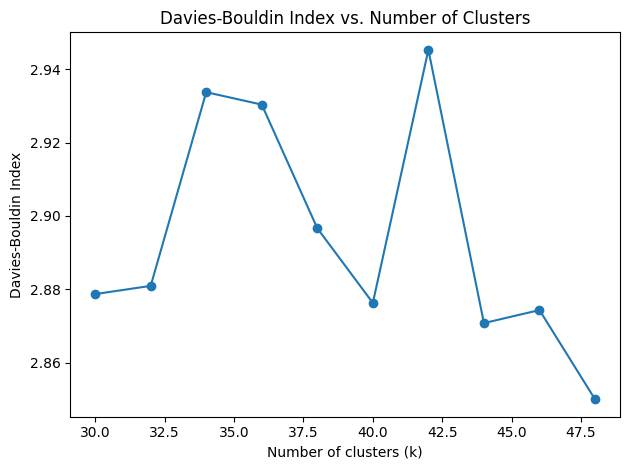

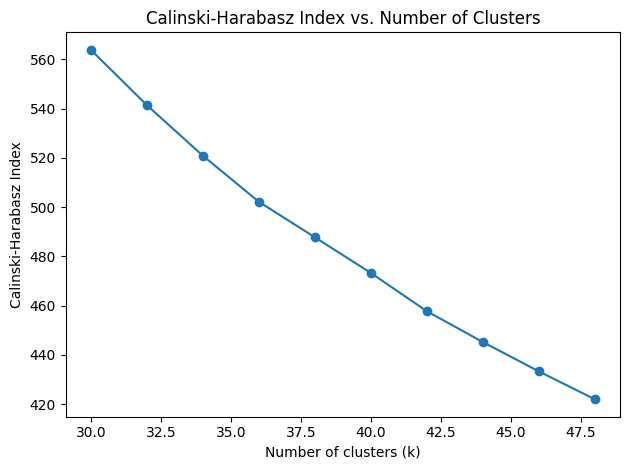

Final clustering with k=10 saved to 'clustered_features.csv'


In [25]:
# === CLUSTERING EVALUATION ===
K_RANGE = range(30, 50, 2)
inertias = []
silhouettes = []
db_indices = []
ch_indices = []

for k in K_RANGE:
    print(k)
    kmeans = KMeans(n_clusters=k, random_state=0)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    db_indices.append(davies_bouldin_score(X_scaled, labels))
    ch_indices.append(calinski_harabasz_score(X_scaled, labels))

# === PLOTTING ===
# 1. Distortion (Inertia)
plt.figure()
plt.plot(list(K_RANGE), inertias, marker='o')
plt.title("Elbow Method: Distortion vs. Number of Clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Distortion (Inertia)")
plt.tight_layout()
plt.show()

# 2. Silhouette Score
plt.figure()
plt.plot(list(K_RANGE), silhouettes, marker='o')
plt.title("Silhouette Score vs. Number of Clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

# 3. Davies-Bouldin Index
plt.figure()
plt.plot(list(K_RANGE), db_indices, marker='o')
plt.title("Davies-Bouldin Index vs. Number of Clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Davies-Bouldin Index")
plt.tight_layout()
plt.show()

# 4. Calinski-Harabasz Index
plt.figure()
plt.plot(list(K_RANGE), ch_indices, marker='o')
plt.title("Calinski-Harabasz Index vs. Number of Clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Calinski-Harabasz Index")
plt.tight_layout()
plt.show()

# Optional: perform final clustering at selected k and save labels
BEST_K = 10  # choose based on the above plots
kmeans_final = KMeans(n_clusters=BEST_K, random_state=0).fit(X_scaled)
df["cluster"] = kmeans_final.labels_
df.to_csv("clustered_features.csv", index=False)
print(f"Final clustering with k={BEST_K} saved to 'clustered_features.csv'")

In [37]:
best_k = 30
kmeans = KMeans(n_clusters=best_k, random_state=0)
labels = kmeans.fit_predict(X_scaled)

In [40]:
df['label'] = labels

In [42]:
df.to_csv("cluster_results_40000.csv", index=False)

In [49]:
df['label'].value_counts()

5     1988
18    1833
22    1761
16    1717
17    1688
20    1627
23    1596
7     1530
27    1516
21    1487
2     1349
4     1324
26    1285
1     1282
11    1275
10    1251
25    1234
13    1223
8     1204
19    1195
3     1151
12    1135
28    1132
9     1102
15    1099
6     1057
0     1056
14    1021
29     954
24     928
Name: label, dtype: int64